In [3]:
import pandas as pd
import sys
from pathlib import Path
import os
os.chdir(Path.cwd().parent)
from src.detect_fake_reviews import load_csv

In [6]:
import pandas as pd

df = load_csv()
df.head()

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


In [7]:
df.shape

(1600, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   deceptive  1600 non-null   object
 1   hotel      1600 non-null   object
 2   polarity   1600 non-null   object
 3   source     1600 non-null   object
 4   text       1600 non-null   object
dtypes: object(5)
memory usage: 62.6+ KB


In [9]:
df.describe(include="all")

,deceptive,hotel,polarity,source,text
count,1600,1600,1600,1600,1600
unique,2,20,2,3,1596
top,truthful,conrad,positive,MTurk,The Omni was chosen for it's location whichwor...
freq,800,80,800,800,2


In [10]:
df["deceptive"].value_counts()

deceptive
truthful     800
deceptive    800
Name: count, dtype: int64

In [11]:
df["hotel"].value_counts()

hotel
conrad              80
hyatt               80
allegro             80
intercontinental    80
palmer              80
sofitel             80
monaco              80
james               80
hilton              80
talbott             80
hardrock            80
affinia             80
ambassador          80
swissotel           80
homewood            80
knickerbocker       80
sheraton            80
fairmont            80
omni                80
amalfi              80
Name: count, dtype: int64

In [12]:
df["polarity"].value_counts()

polarity
positive    800
negative    800
Name: count, dtype: int64

In [13]:
df["source"].value_counts()

source
MTurk          800
TripAdvisor    400
Web            400
Name: count, dtype: int64

In [14]:
summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "hotels": df["hotel"].nunique(),
    "sources": df["source"].nunique(),
    "deceptive_labels": df["deceptive"].unique().tolist(),
    "polarity_labels": df["polarity"].unique().tolist()
}

summary

{'rows': 1600,
 'columns': 5,
 'hotels': 20,
 'sources': 3,
 'deceptive_labels': ['truthful', 'deceptive'],
 'polarity_labels': ['positive', 'negative']}

In [15]:
import re
from collections import Counter

CATEGORY_KEYWORDS = {
    "food": [
        "breakfast", "restaurant", "food", "meal", "meals", "dinner", "lunch",
        "coffee", "bar", "buffet", "menu", "eat", "eating", "drink", "drinks",
        "waiter", "waitress", "kitchen", "delicious", "pricey"
    ],
    "service": [
        "staff", "service", "friendly", "helpful", "rude", "manager", "concierge",
        "reception", "check", "checkin", "checkout", "front", "employee",
        "employees", "people", "attentive", "professional", "slow", "quick"
    ],
    "comfort": [
        "comfortable", "comfort", "bed", "beds", "sleep", "slept", "quiet",
        "noise", "noisy", "pillow", "pillows", "mattress", "cozy", "relaxing",
        "temperature", "air", "heating", "ac"
    ],
    "cleanliness": [
        "clean", "cleaner", "cleanliness", "dirty", "spotless", "bathroom",
        "bathrooms", "smell", "smelled", "stain", "stains", "dust", "towels",
        "housekeeping", "maid", "shower", "mold"
    ],
    "space": [
        "space", "spacious", "small", "large", "tiny", "size", "suite", "closet",
        "bath", "layout", "area", "view", "floor", "lobby", "location",
        "walk", "walking", "distance", "close"
    ]
}

def tokenize(text):
    return re.findall(r"[a-zA-Z]{3,}", str(text).lower())

def category_hits(text):
    tokens = tokenize(text)
    counts = Counter(tokens)

    return {
        category: sum(counts[word] for word in words)
        for category, words in CATEGORY_KEYWORDS.items()
    }

def primary_category(text):
    hits = category_hits(text)
    top_category = max(hits, key=hits.get)

    if hits[top_category] == 0:
        return "uncategorized"

    return top_category

In [16]:
category_scores = df["text"].apply(category_hits).apply(pd.Series)

df_with_categories = pd.concat(
    [df, category_scores.add_prefix("hits_")],
    axis=1
)

df_with_categories["primary_category"] = df_with_categories["text"].apply(primary_category)

df_with_categories.head()

,deceptive,hotel,polarity,source,text,hits_food,hits_service,hits_comfort,hits_cleanliness,hits_space,primary_category
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...,4,4,0,1,2,food
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...,1,0,2,0,5,space
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...,1,2,1,1,2,service
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...,0,5,0,0,2,service
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...,0,1,0,1,2,space


In [17]:
category_summary = (
    df_with_categories
    .groupby("primary_category")
    .agg(
        reviews=("text", "count"),
        truthful_reviews=("deceptive", lambda x: (x == "truthful").sum()),
        deceptive_reviews=("deceptive", lambda x: (x == "deceptive").sum()),
        positive_reviews=("polarity", lambda x: (x == "positive").sum()),
        negative_reviews=("polarity", lambda x: (x == "negative").sum())
    )
    .reset_index()
)

category_summary["share_of_reviews"] = (
    category_summary["reviews"] / len(df_with_categories) * 100
).round(2)

category_summary["positive_rate"] = (
    category_summary["positive_reviews"] / category_summary["reviews"] * 100
).round(2)

category_summary["deceptive_rate"] = (
    category_summary["deceptive_reviews"] / category_summary["reviews"] * 100
).round(2)

category_summary.sort_values("reviews", ascending=False)

,primary_category,reviews,truthful_reviews,deceptive_reviews,positive_reviews,negative_reviews,share_of_reviews,positive_rate,deceptive_rate
3,service,764,344,420,348,416,47.75,45.55,54.97
4,space,310,220,90,193,117,19.38,62.26,29.03
2,food,236,98,138,143,93,14.75,60.59,58.47
1,comfort,165,91,74,84,81,10.31,50.91,44.85
0,cleanliness,103,40,63,21,82,6.44,20.39,61.17
5,uncategorized,22,7,15,11,11,1.38,50.00,68.18


In [18]:
category_summary = (
    df_with_categories
    .groupby("primary_category")
    .agg(
        reviews=("text", "count"),
        truthful_reviews=("deceptive", lambda x: (x == "truthful").sum()),
        deceptive_reviews=("deceptive", lambda x: (x == "deceptive").sum()),
        positive_reviews=("polarity", lambda x: (x == "positive").sum()),
        negative_reviews=("polarity", lambda x: (x == "negative").sum())
    )
    .reset_index()
)

category_summary["share_of_reviews"] = (
    category_summary["reviews"] / len(df_with_categories) * 100
).round(2)

category_summary["positive_rate"] = (
    category_summary["positive_reviews"] / category_summary["reviews"] * 100
).round(2)

category_summary["deceptive_rate"] = (
    category_summary["deceptive_reviews"] / category_summary["reviews"] * 100
).round(2)

category_summary.sort_values("reviews", ascending=False)

,primary_category,reviews,truthful_reviews,deceptive_reviews,positive_reviews,negative_reviews,share_of_reviews,positive_rate,deceptive_rate
3,service,764,344,420,348,416,47.75,45.55,54.97
4,space,310,220,90,193,117,19.38,62.26,29.03
2,food,236,98,138,143,93,14.75,60.59,58.47
1,comfort,165,91,74,84,81,10.31,50.91,44.85
0,cleanliness,103,40,63,21,82,6.44,20.39,61.17
5,uncategorized,22,7,15,11,11,1.38,50.00,68.18


In [19]:
hotel_category_rank = (
    df_with_categories
    .groupby(["hotel", "primary_category"])
    .agg(
        reviews=("text", "count"),
        positive_reviews=("polarity", lambda x: (x == "positive").sum()),
        negative_reviews=("polarity", lambda x: (x == "negative").sum()),
        truthful_reviews=("deceptive", lambda x: (x == "truthful").sum()),
        deceptive_reviews=("deceptive", lambda x: (x == "deceptive").sum())
    )
    .reset_index()
)

hotel_category_rank["positive_rate"] = (
    hotel_category_rank["positive_reviews"] / hotel_category_rank["reviews"]
)

hotel_category_rank["truthful_rate"] = (
    hotel_category_rank["truthful_reviews"] / hotel_category_rank["reviews"]
)

hotel_category_rank["category_score_0_10"] = (
    10 * (
        0.65 * hotel_category_rank["positive_rate"]
        + 0.35 * hotel_category_rank["truthful_rate"]
    )
).round(2)

hotel_category_rank["positive_rate"] = (hotel_category_rank["positive_rate"] * 100).round(2)
hotel_category_rank["truthful_rate"] = (hotel_category_rank["truthful_rate"] * 100).round(2)

hotel_category_rank = hotel_category_rank.sort_values(
    ["category_score_0_10", "reviews"],
    ascending=[False, False]
)

hotel_category_rank.head(20)

,hotel,primary_category,reviews,positive_reviews,negative_reviews,truthful_reviews,deceptive_reviews,positive_rate,truthful_rate,category_score_0_10
105,talbott,cleanliness,1,1,0,1,0,100.00,100.00,10.00
81,omni,space,8,8,0,5,3,100.00,62.50,8.69
104,swissotel,space,16,13,3,12,4,81.25,75.00,7.91
41,hilton,space,17,15,2,10,7,88.24,58.82,7.79
53,hyatt,space,18,14,4,13,5,77.78,72.22,7.58
18,ambassador,food,8,7,1,4,4,87.50,50.00,7.44
35,hardrock,space,15,11,4,11,4,73.33,73.33,7.33
30,fairmont,space,13,8,5,12,1,61.54,92.31,7.23
15,amalfi,space,14,9,5,12,2,64.29,85.71,7.18
13,amalfi,food,14,13,1,4,10,92.86,28.57,7.04


In [20]:
stable_rank = hotel_category_rank[hotel_category_rank["reviews"] >= 5]

stable_rank.head(20)

,hotel,primary_category,reviews,positive_reviews,negative_reviews,truthful_reviews,deceptive_reviews,positive_rate,truthful_rate,category_score_0_10
81,omni,space,8,8,0,5,3,100.00,62.50,8.69
104,swissotel,space,16,13,3,12,4,81.25,75.00,7.91
41,hilton,space,17,15,2,10,7,88.24,58.82,7.79
53,hyatt,space,18,14,4,13,5,77.78,72.22,7.58
18,ambassador,food,8,7,1,4,4,87.50,50.00,7.44
35,hardrock,space,15,11,4,11,4,73.33,73.33,7.33
30,fairmont,space,13,8,5,12,1,61.54,92.31,7.23
15,amalfi,space,14,9,5,12,2,64.29,85.71,7.18
13,amalfi,food,14,13,1,4,10,92.86,28.57,7.04
106,talbott,comfort,10,7,3,7,3,70.00,70.00,7.00


In [21]:
!pip install wordcloud matplotlib -q

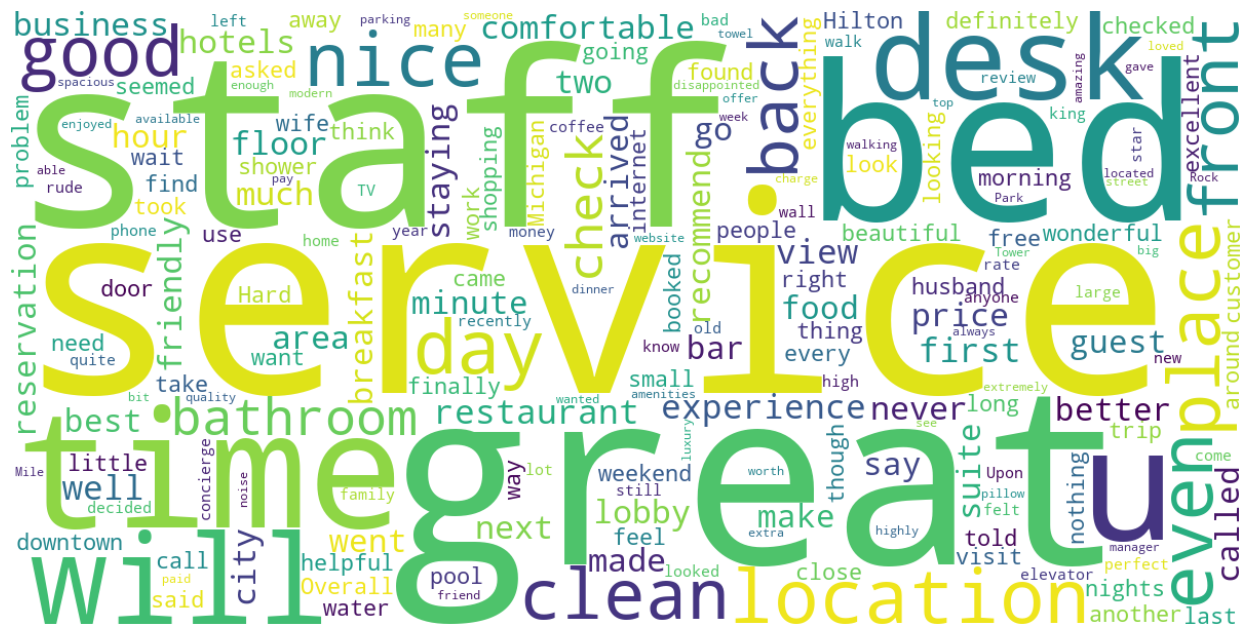

In [22]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

text = " ".join(df["text"].dropna().astype(str))

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "hotel", "room", "rooms", "stay", "stayed", "night",
    "chicago", "one", "get", "got", "really", "very"
])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    collocations=False
).generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [23]:
!pip install wordcloud matplotlib -q


In [24]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    "hotel", "room", "rooms", "stay", "stayed", "night",
    "chicago", "one", "get", "got", "really", "very",
    "staff", "service", "great", "nice", "good", "bed",
    "time", "day", "place"
])

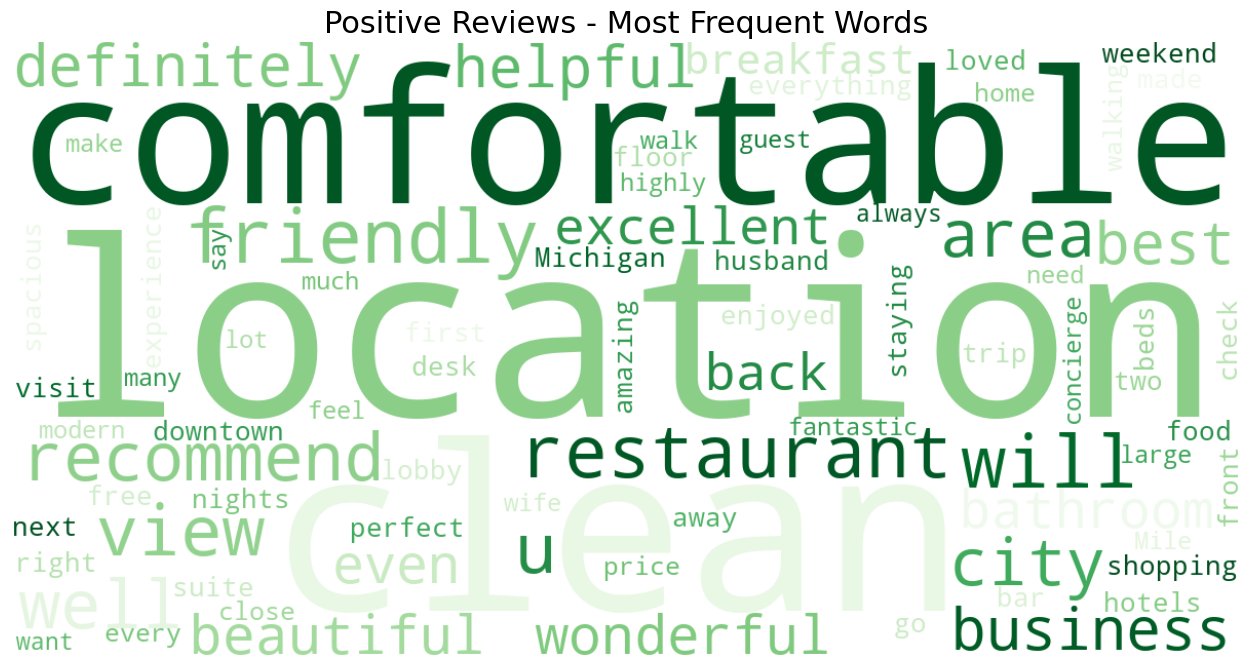

In [25]:
positive_text = " ".join(
    df[df["polarity"] == "positive"]["text"]
    .dropna()
    .astype(str)
)

positive_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    collocations=False,
    max_words=80,
    colormap="Greens"
).generate(positive_text)

plt.figure(figsize=(16, 8))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews - Most Frequent Words", fontsize=22)
plt.show()

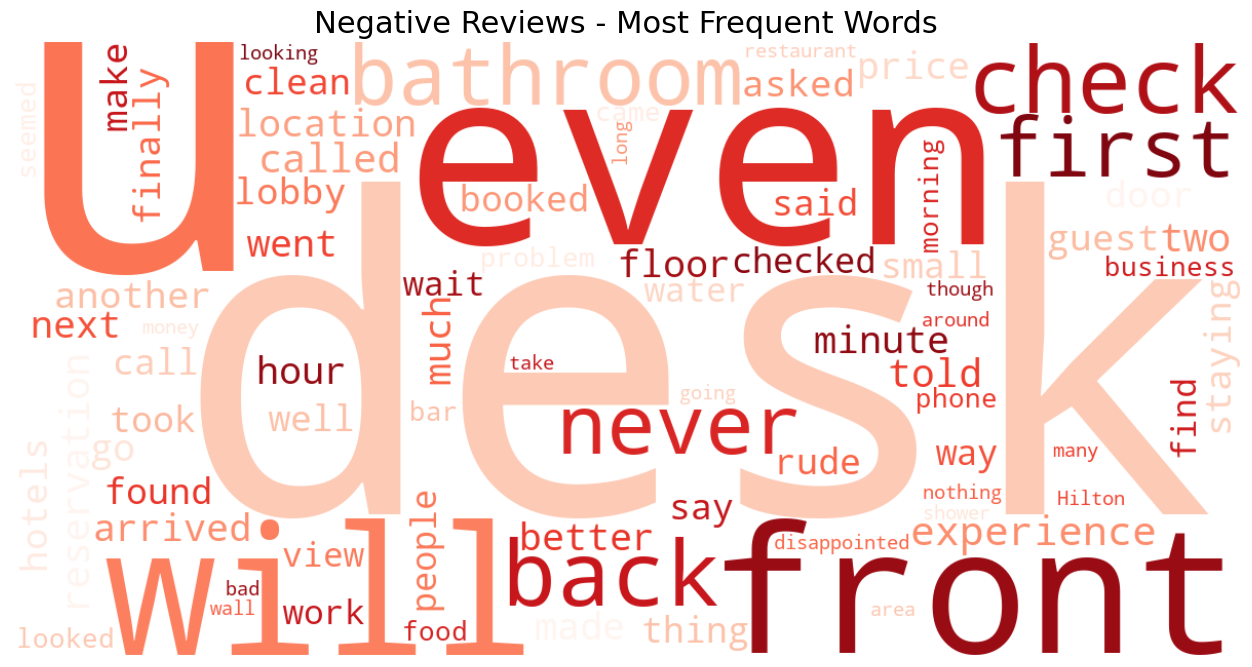

In [26]:
negative_text = " ".join(
    df[df["polarity"] == "negative"]["text"]
    .dropna()
    .astype(str)
)

negative_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    collocations=False,
    max_words=80,
    colormap="Reds"
).generate(negative_text)

plt.figure(figsize=(16, 8))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews - Most Frequent Words", fontsize=22)
plt.show()